In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("synthetic_5g_kpis.csv")

# 1. Análisis exploratorio:

In [3]:
display(df.head(10))

,time,site,cell_id,user_id,slice_id,rsrp_dbm,rsrq_db,sinr_db,throughput_dl_mbps,throughput_ul_mbps,latency_ms,jitter_ms,packet_loss_pct,prb_utilization_pct,ho_success_rate,energy_watts,alarm_rate
0,2025-11-07 10:00:00,madrid_centro,cell_01,UE_030,eMBB,-87.140230,-11.484814,16.483281,49.161669,14.888458,12.653541,0.720971,0.628676,17.207587,82.296656,34.988537,0.017703
1,2025-11-07 10:00:00,madrid_centro,cell_01,UE_016,eMBB,-83.121510,-11.201277,18.541531,101.767107,22.837317,10.797347,1.074207,0.584347,47.965868,82.708306,45.761220,0.017292
2,2025-11-07 10:00:00,madrid_centro,cell_01,UE_025,eMBB,-91.325596,-7.816015,33.891565,95.215972,36.598625,16.838923,1.568244,0.500432,83.872794,85.778313,47.338993,0.014222
3,2025-11-07 10:00:00,madrid_centro,cell_01,UE_018,eMBB,-88.599221,-10.921278,25.285611,56.990581,13.004387,15.089987,2.396747,0.663005,66.872366,84.057122,50.639467,0.015943
4,2025-11-07 10:00:00,madrid_centro,cell_01,UE_009,eMBB,-86.035829,-11.246955,12.459234,88.330488,23.410818,12.868497,2.099376,0.773328,81.992940,81.491847,51.182558,0.018508
5,2025-11-07 10:00:00,madrid_centro,cell_01,UE_010,eMBB,-79.982336,-9.276728,16.774401,106.684505,37.786951,23.478284,1.427438,0.576264,67.227912,82.354880,48.262990,0.017645
6,2025-11-07 10:00:00,madrid_centro,cell_01,UE_020,eMBB,-92.093752,-7.915017,24.517662,72.173757,25.340944,8.533839,0.044890,0.527236,60.380007,83.903532,49.822208,0.016096
7,2025-11-07 10:00:00,madrid_centro,cell_01,UE_026,eMBB,-83.356244,-11.059520,22.566337,95.500450,34.522270,12.169212,1.890047,0.561505,61.941551,83.513267,46.284833,0.016487
8,2025-11-07 10:00:00,madrid_centro,cell_01,UE_013,eMBB,-78.631332,-10.583905,6.724120,77.522433,20.739036,12.478107,1.086525,0.706784,66.910359,80.344824,54.040629,0.019655
9,2025-11-07 10:00:00,madrid_centro,cell_01,UE_001,eMBB,-84.127111,-9.484899,19.627770,60.414580,15.524620,11.388272,0.706218,0.535943,21.624576,82.925554,39.336727,0.017074


In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43200 entries, 0 to 43199
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   time                 43200 non-null  object 
 1   site                 43200 non-null  object 
 2   cell_id              43200 non-null  object 
 3   user_id              43200 non-null  object 
 4   slice_id             43200 non-null  object 
 5   rsrp_dbm             43200 non-null  float64
 6   rsrq_db              43200 non-null  float64
 7   sinr_db              43200 non-null  float64
 8   throughput_dl_mbps   43200 non-null  float64
 9   throughput_ul_mbps   43200 non-null  float64
 10  latency_ms           43200 non-null  float64
 11  jitter_ms            43200 non-null  float64
 12  packet_loss_pct      43200 non-null  float64
 13  prb_utilization_pct  43200 non-null  float64
 14  ho_success_rate      43200 non-null  float64
 15  energy_watts         43200 non-null 

None

Tenemos series temporales de:
- time
Momento exacto en el que se tomó la medición (timestamp por minuto).

- site
Nombre del emplazamiento o localización física donde está la estación base.

- cell_id
Identificador de la celda dentro del site (cada estación tiene varias celdas).

- user_id
Identificador del usuario o dispositivo conectado (UE = User Equipment).

- slice_id
Tipo de slice 5G al que pertenece el usuario: eMBB (alta capacidad), URLLC (baja latencia), IoT (bajo consumo).

- rsrp_dbm
Potencia de señal recibida. Mide cuánta señal llega al usuario. Valores más negativos indican peor señal.

- rsrq_db
Calidad de señal recibida. Relaciona señal con interferencia. Más negativo suele significar peor calidad.

- sinr_db
Relación señal/interferencia/ruido. Valores altos indican buena calidad radio.

- throughput_dl_mbps
Velocidad de descarga conseguida por el usuario.

- throughput_ul_mbps
Velocidad de subida conseguida por el usuario.

- latency_ms
Tiempo que tarda un paquete en ir de origen a destino (ms). Importante para URLLC.

- jitter_ms
Variación entre los tiempos de llegada de paquetes. Afecta a aplicaciones tiempo real.

- packet_loss_pct
Porcentaje de paquetes perdidos. A mayor pérdida, peor rendimiento.

- prb_utilization_pct
Porcentaje de uso de recursos de radio (PRB). Indica carga de la celda.

- ho_success_rate
Porcentaje de éxito en handovers entre celdas. Importante para movilidad.

- energy_watts
Consumo energético estimado de la celda en ese instante.

- alarm_rate
Frecuencia o probabilidad de alarmas asociadas al estado de la celda.

## 1.1. Análisis de distribuciones de las variables categóricas:

In [5]:
# Seleccionar columnas categóricas
cat_cols = ["site", "cell_id", "user_id", "slice_id"]

# Mostrar número de categorías y distribución
for col in cat_cols:
    print(f"\n=== {col.upper()} ===")
    print(df[col].value_counts())
    print("\nProporciones:")
    print(df[col].value_counts(normalize=True) * 100)


=== SITE ===
site
madrid_centro    21600
valencia_fp      21600
Name: count, dtype: int64

Proporciones:
site
madrid_centro    50.0
valencia_fp      50.0
Name: proportion, dtype: float64

=== CELL_ID ===
cell_id
cell_01    14400
cell_02    14400
cell_03    14400
Name: count, dtype: int64

Proporciones:
cell_id
cell_01    33.333333
cell_02    33.333333
cell_03    33.333333
Name: proportion, dtype: float64

=== USER_ID ===
user_id
UE_019    1499
UE_025    1480
UE_007    1479
UE_001    1474
UE_008    1472
UE_020    1469
UE_021    1464
UE_023    1463
UE_022    1457
UE_029    1456
UE_009    1452
UE_015    1452
UE_002    1447
UE_026    1446
UE_013    1445
UE_011    1444
UE_016    1437
UE_018    1435
UE_017    1434
UE_004    1427
UE_030    1424
UE_014    1424
UE_006    1419
UE_024    1419
UE_003    1416
UE_010    1406
UE_012    1406
UE_027    1394
UE_005    1393
UE_028    1367
Name: count, dtype: int64

Proporciones:
user_id
UE_019    3.469907
UE_025    3.425926
UE_007    3.423611
UE_001    

## 1.2. Análisis de las series temporales:

Como tenemos demasiados datos cada muy poco tiempo, hay que agrupar las mediciones cada 5 minutos, para poder ver la señal.

C:\Users\User\AppData\Local\Temp\ipykernel_24808\1271017589.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_agg = df.groupby(df["time"].dt.floor('5T'))[numeric_cols].mean().reset_index()


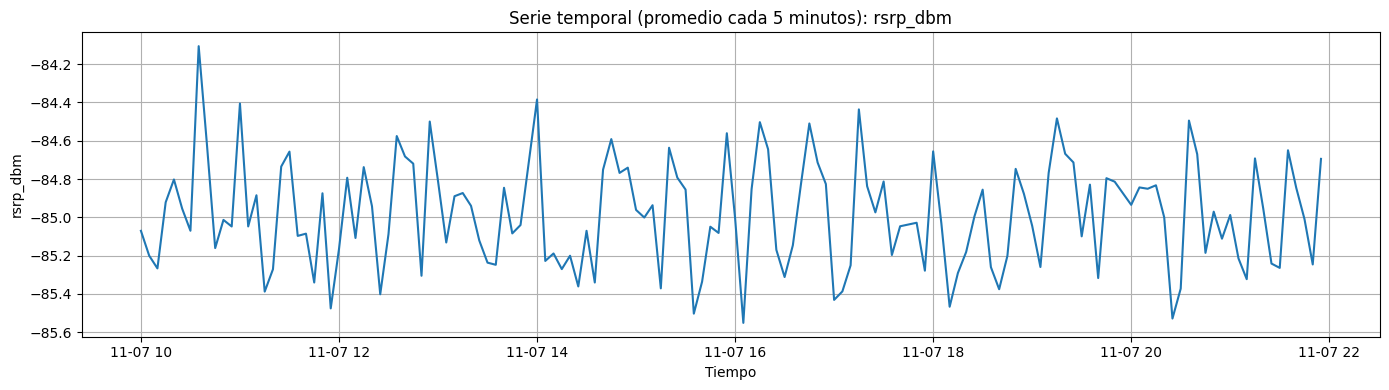

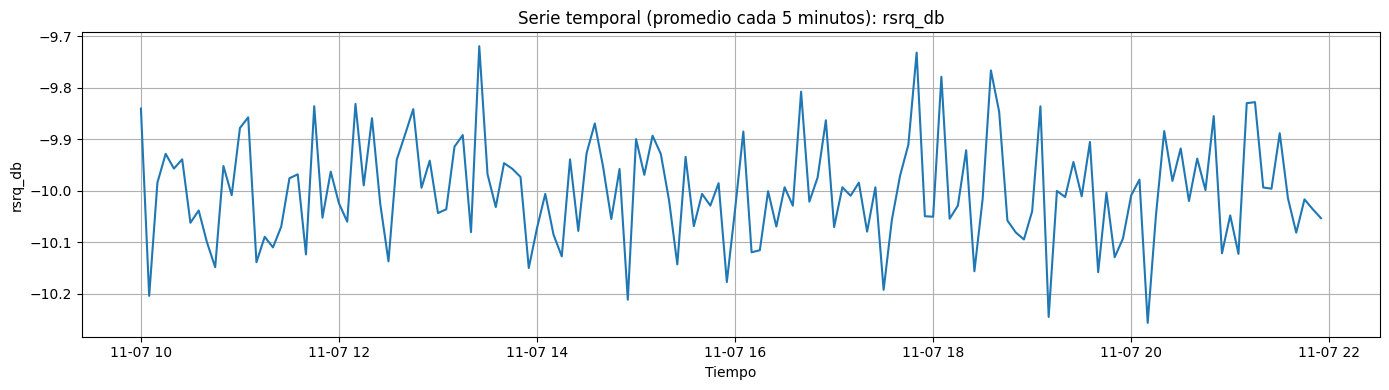

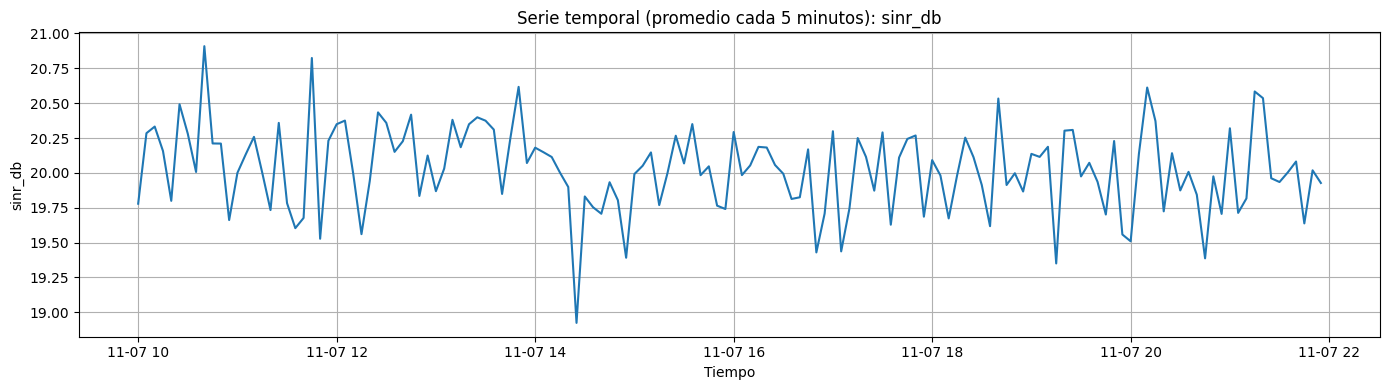

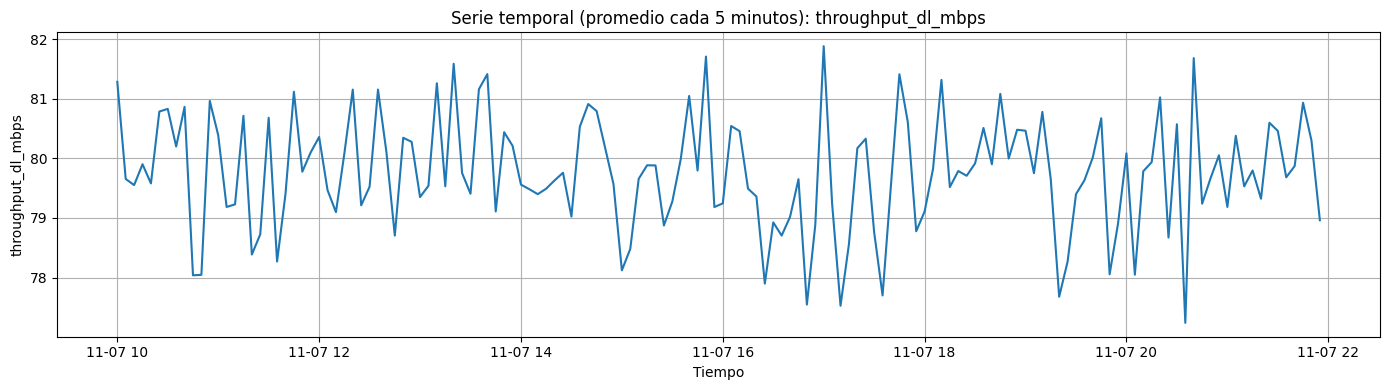

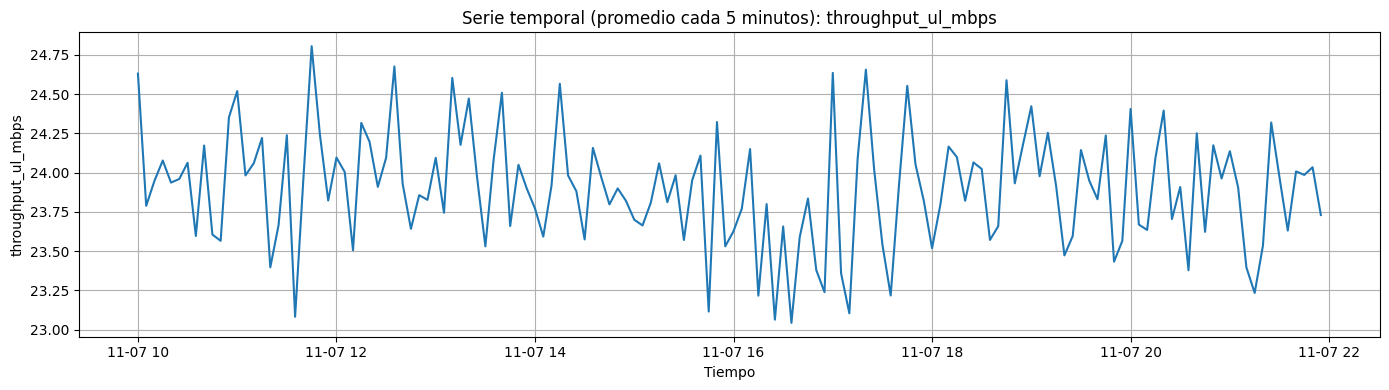

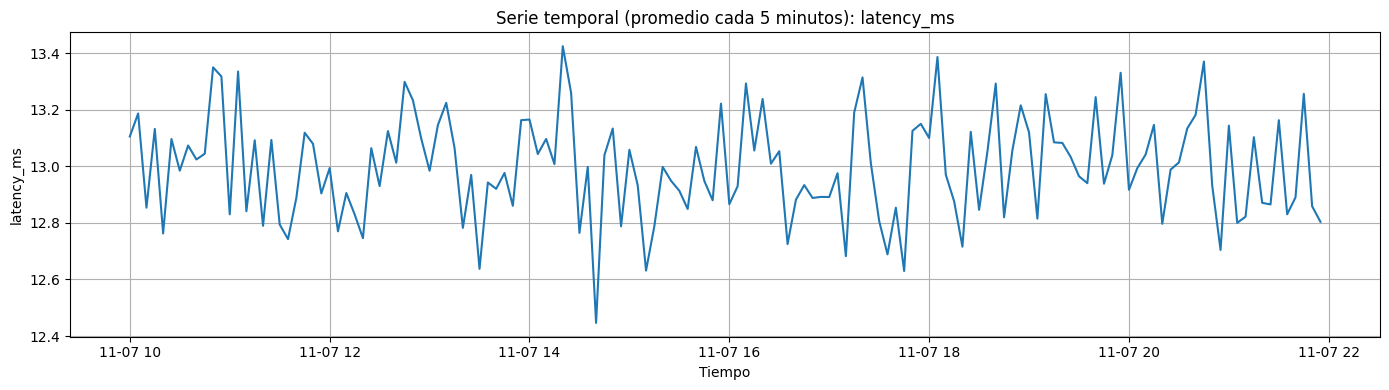

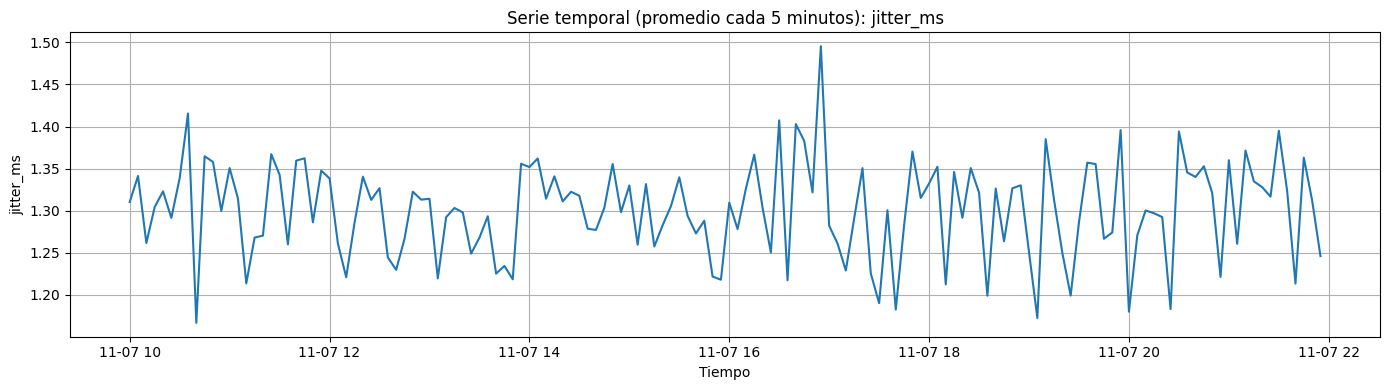

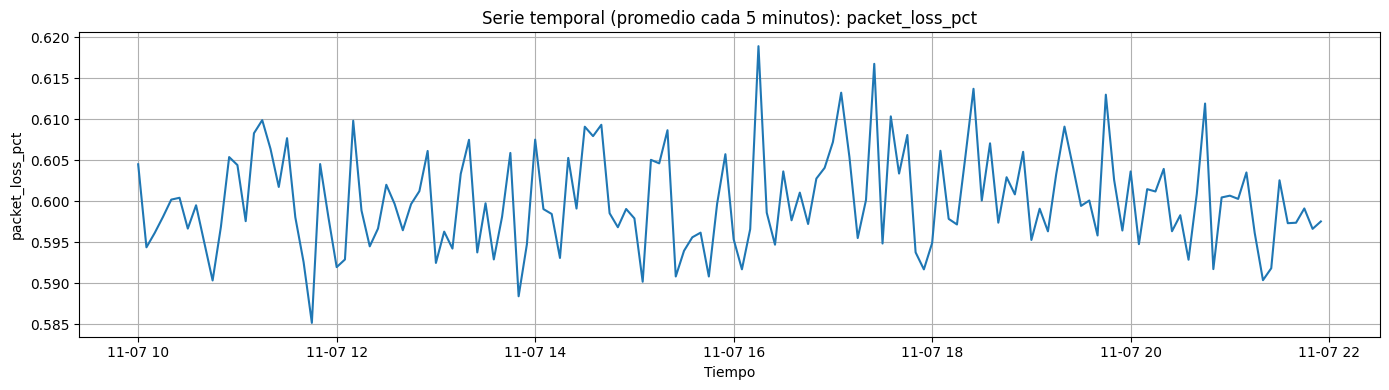

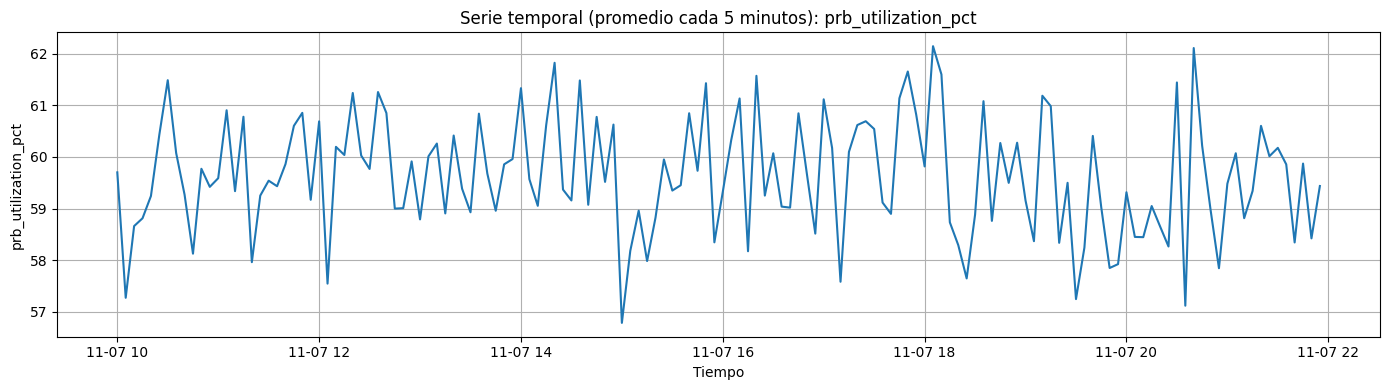

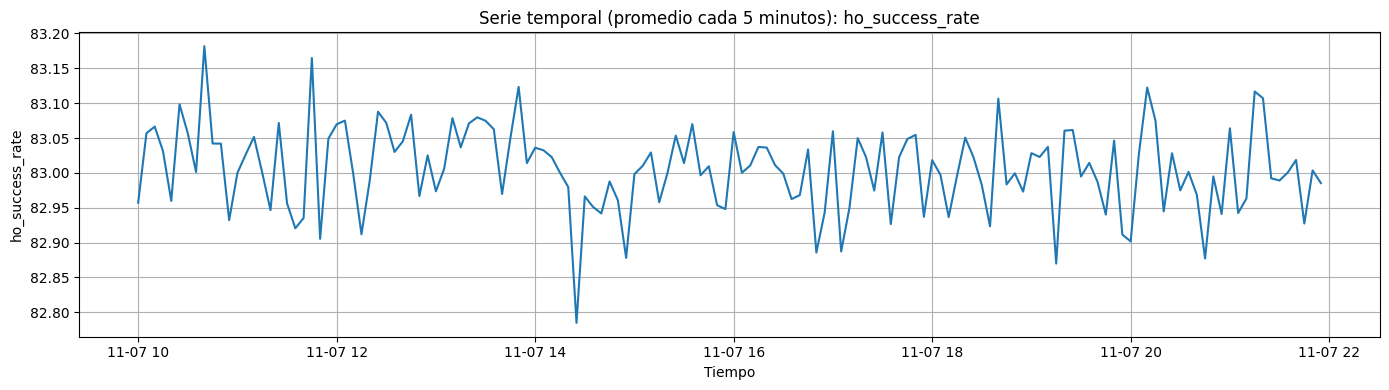

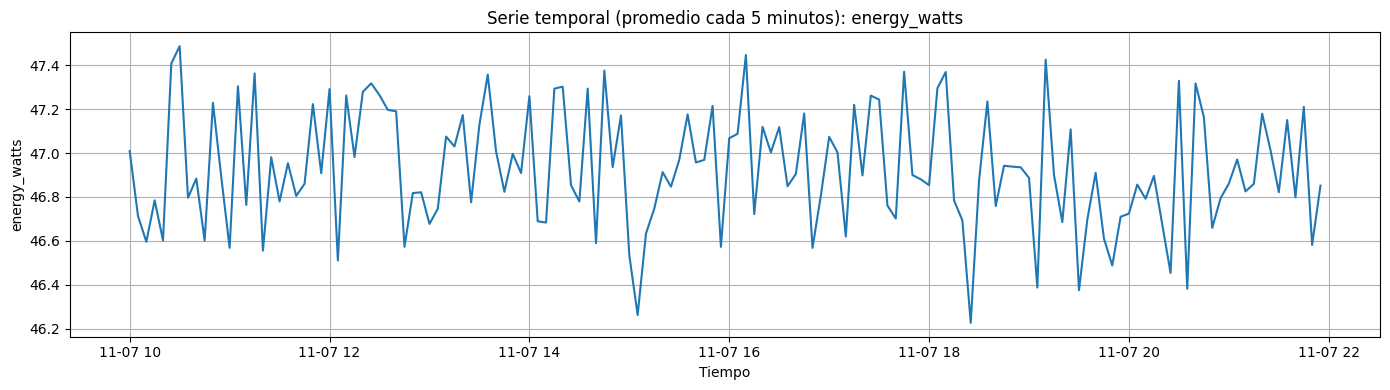

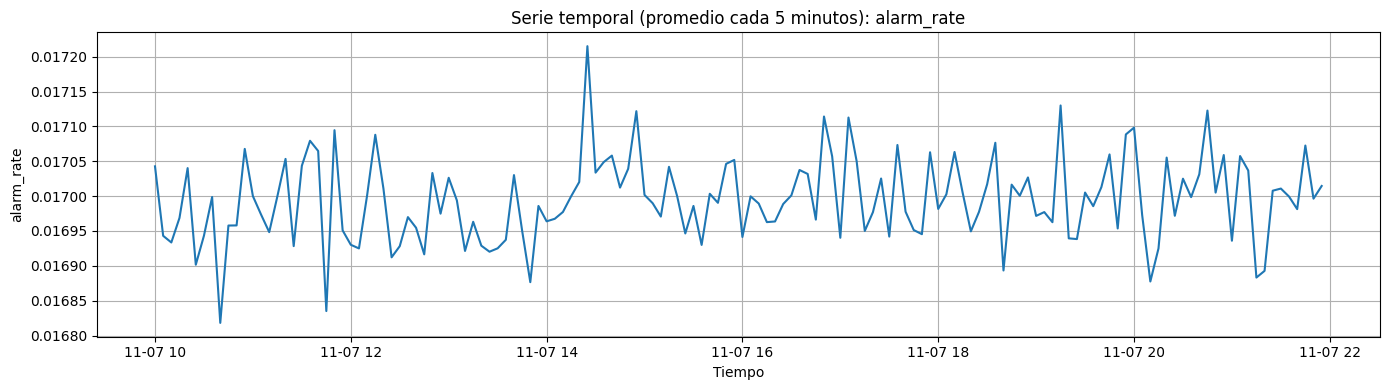

In [25]:
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

# Agrupar cada 5 minutos
df_agg = df.groupby(df["time"].dt.floor('5T'))[numeric_cols].mean().reset_index()
df_agg = df_agg.rename(columns={"time": "time"})

# Graficar
for col in numeric_cols:
    plt.figure(figsize=(14, 4))
    plt.plot(df_agg["time"], df_agg[col])
    plt.title(f"Serie temporal (promedio cada 5 minutos): {col}")
    plt.xlabel("Tiempo")
    plt.ylabel(col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Voy a descomponer las gráficas para ver sus características, para ello hay que sacar las frecuencias de cada una:

In [13]:
# Función para el cálculo de frecuencia y periodo dominante
def fft_analysis(signal):
    # Linear detrending
    slope, intercept = np.polyfit(np.arange(len(signal)), signal, 1) # Ajuste recta
    trend = np.arange(len(signal)) * slope + intercept #tendencia lineal para cada punto
    detrended = signal - trend # Eliminación de la tendencia lineal  componentes dominantes
    fft_values = np.fft.fft(detrended) # frecuencias correspondientes a cada componente en la FFT
    frequencies = np.fft.fftfreq(len(fft_values)) #Valores de las frecuencias
    # Remove negative frequencies and sort
    positive_frequencies = frequencies[frequencies > 0]
    magnitudes = np.abs(fft_values)[frequencies > 0] #Intensidad de las comp. freq
    # Identify dominant frequency
    dominant_frequency = positive_frequencies[np.argmax(magnitudes)] #Indice freq.dom
    print(f"Dominant Frequency: {dominant_frequency:.3f}")
    # Convert frequency to period (e.g., days, weeks, months, etc.)
    dominant_period = 1 / dominant_frequency
    print(f"Dominant Period: {dominant_period:.2f} time units")
    return dominant_period, positive_frequencies, magnitudes

In [23]:
def seas_decomp_plots(original, decomposition):
    _, axes = plt.subplots(4, 1, sharex=True, sharey=False, figsize=(7, 5))
    axes[0].plot(original, label='Original')
    axes[0].legend(loc='upper left')
    axes[1].plot(decomposition.trend, label='Trend')
    axes[1].legend(loc='upper left')
    axes[2].plot(decomposition.seasonal, label='Seasonality')
    axes[2].legend(loc='upper left')
    axes[3].plot(decomposition.resid, label='Residuals')
    axes[3].legend(loc='upper left')
    plt.show()

rsrp_dbm
Dominant Frequency: 0.174
Dominant Period: 5.76 time units


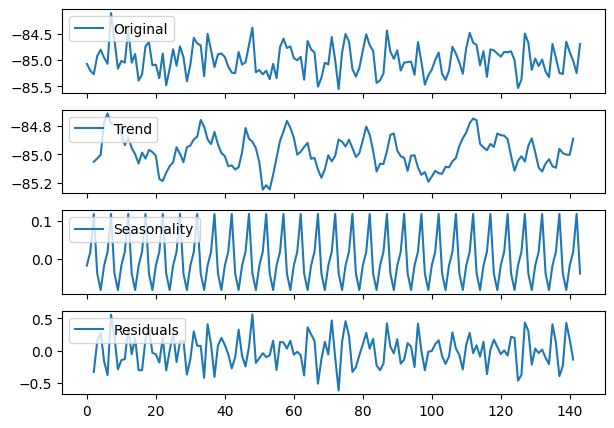

rsrq_db
Dominant Frequency: 0.097
Dominant Period: 10.29 time units


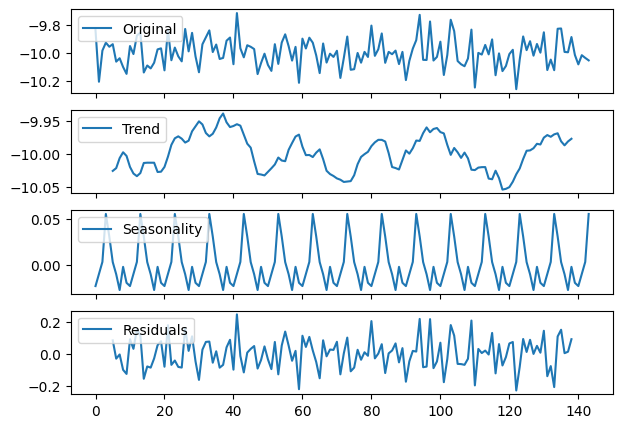

sinr_db
Dominant Frequency: 0.236
Dominant Period: 4.24 time units


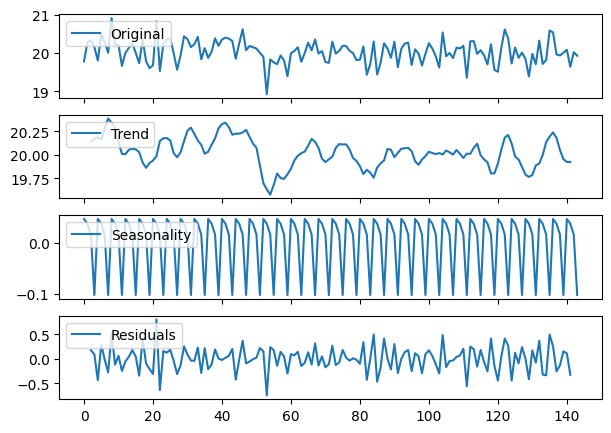

throughput_dl_mbps
Dominant Frequency: 0.222
Dominant Period: 4.50 time units


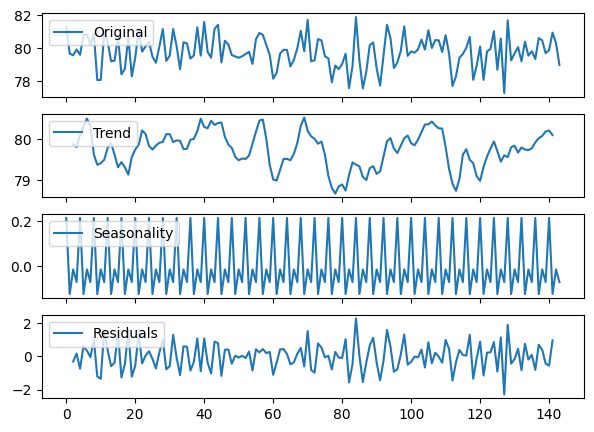

throughput_ul_mbps
Dominant Frequency: 0.014
Dominant Period: 72.00 time units


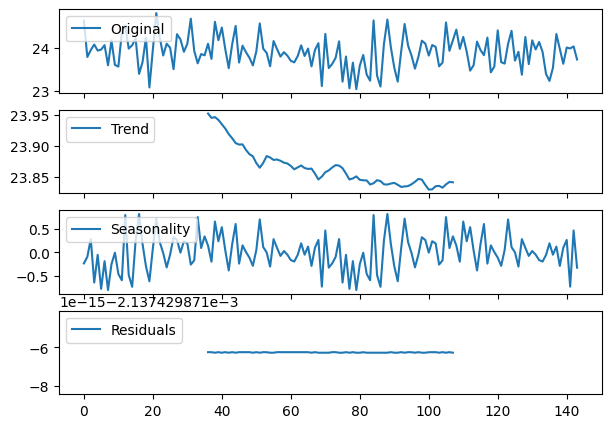

latency_ms
Dominant Frequency: 0.299
Dominant Period: 3.35 time units


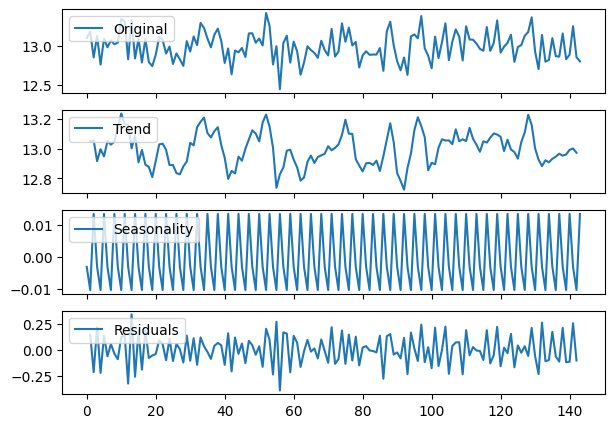

jitter_ms
Dominant Frequency: 0.368
Dominant Period: 2.72 time units


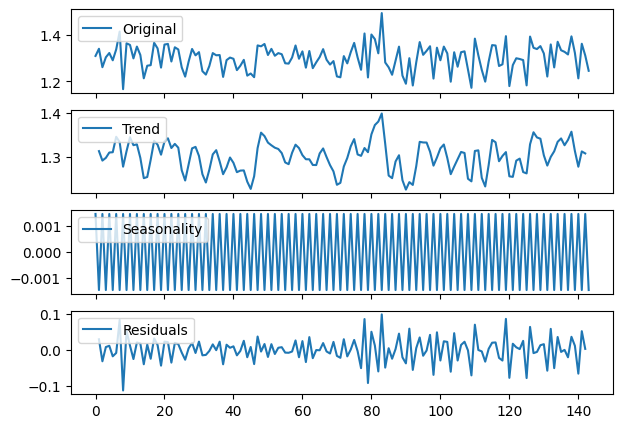

packet_loss_pct
Dominant Frequency: 0.271
Dominant Period: 3.69 time units


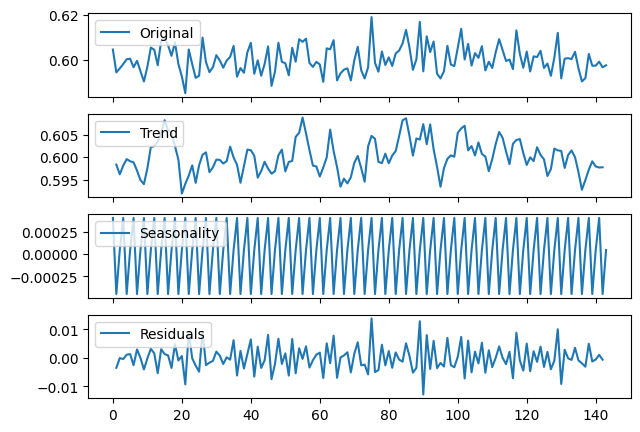

prb_utilization_pct
Dominant Frequency: 0.049
Dominant Period: 20.57 time units


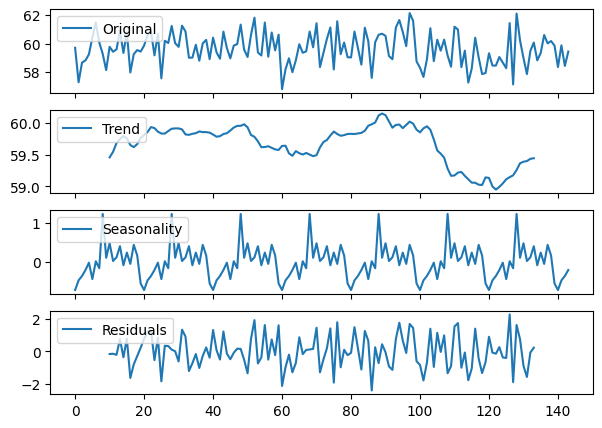

ho_success_rate
Dominant Frequency: 0.236
Dominant Period: 4.24 time units


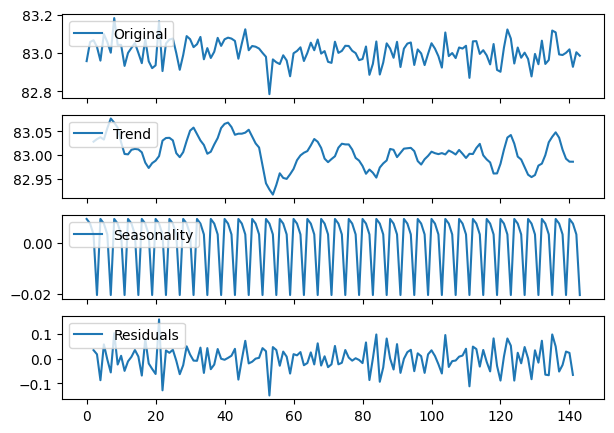

energy_watts
Dominant Frequency: 0.236
Dominant Period: 4.24 time units


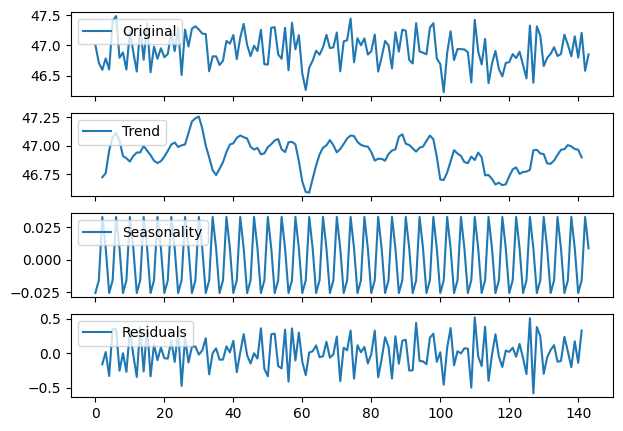

alarm_rate
Dominant Frequency: 0.236
Dominant Period: 4.24 time units


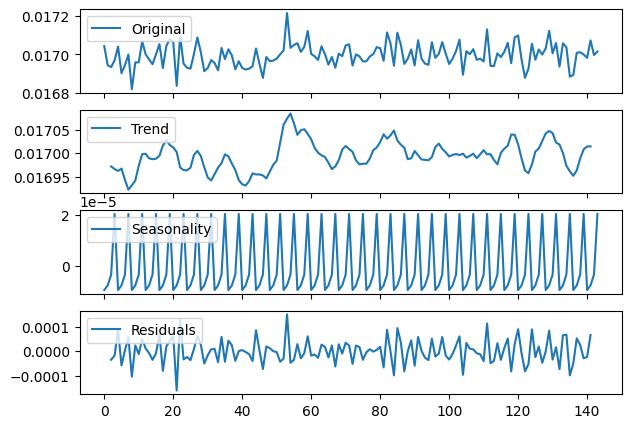

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
for col in numeric_cols:
    print(f'{col}')
    dominant_period,_,_=fft_analysis(df_agg[col])
    additive_decomposition = seasonal_decompose(x=df_agg[col], model='additive', period=int(dominant_period))
    seas_decomp_plots(df_agg[col], additive_decomposition)